<div style="text-align: center;">
  <img src="./imagens/logo_novaims.png" alt="Logo" style="width: 150px; height: auto; margin-bottom: 10px;">
  <h1 style="margin: 0;"><strong>Data Mining Project: Amazing International Airlines Inc.</strong></h1>
  <h2 style="margin: 0;"><strong>Part 1/2: Exploratory Data Analysis</strong></h2>
</div>

<div style="text-align: left; margin-top: 15px;">
  <p style="margin: 0;"><strong>Group 51:</strong></p>
  <ul style="margin: 0; padding-left: 20px;">
    <li>André Ferreira | 20250398</li>
    <li>Fausto Gomes | 20221915</li>
    <li>Maria Francisca Gonçalves | 20221942</li>
    <li>Miguel Matos | 20221925</li>
  </ul>
</div>

---
#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
0. [Context](#introduction)
1. [Imports](#Imports)  
2. [Exploratory Data Analysis - Customer Data](#exploratory-data-analysis)

- 2.1. [Data Understanding](#21-data-understanding)
  - 2.1.1.[Descriptive Analysis](#descriptive-analysis)
  - 2.1.2.[Visualizations](#visualizations)

- 2.2. [GeoData](#geodata)

- 2.3. [Data Cleaning](#data-cleaning)



----

# <span style="color:#0097b2">0. Context</span>
[Back to TOC](#toc)

# <span style="color:#0097b2">1. Imports</span>
[Back to TOC](#toc)

In [28]:
from utils.functions import *

customer_data = pd.read_csv("../data/cleaned_data/customers_data_cleaned.csv", index_col= 0)
flights_data = pd.read_csv("../data/cleaned_data/flights_data_cleaned.csv", index_col= 0)

pd.set_option("display.max_columns", None)

In [29]:
data = pd.merge(
    customer_data, 
    flights_data, 
    on='Loyalty#', 
    how='outer' # To keep all clients registered
)

# The merge might create NaNs for customers in df_clean who had zero flight history
# For clustering, we should fill these with 0
features_to_fill = [
    'TotalFlights', 
    'TotalDistance', 
    'TotalPointsAccumulated', 
    'TotalPointsRedeemed'
]
data[features_to_fill] = data[features_to_fill].fillna(0)

# If 'RecencyInMonths' is NaN (from the 'left' merge), it means they never flew. 
# We can keep the 999 we set earlier, or set it again.
data['RecencyInMonths'] = data['RecencyInMonths'].fillna(999)

In [30]:
customer_data

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,0,1049.0,0,2019,2,1
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaN,3839.61,Standard,0,1027.0,0,2019,3,5
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,0,1274.0,1,2017,7,2
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaN,3839.75,Standard,0,2143.0,0,2016,2,1
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaN,3842.79,2021 Promotion,0,1527.0,0,2017,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16752,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2019-02-27,2019-02-27,NaN,Standard,0,0.0,0,2019,2,4
16753,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,2017-09-20,2017-09-20,NaN,Standard,0,0.0,0,2017,9,5
16754,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,2020-11-28,2020-11-28,NaN,Standard,0,0.0,0,2020,11,3
16755,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,2020-04-09,2020-04-09,NaN,Standard,0,0.0,0,2020,4,4


In [31]:
flights_data

,Loyalty#,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,LastFlightDate,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent
0,100018,229.9,530230.0,53014.30,20562.8,2021-12-01,1.018397,0.048421,0.060858,0.074292,0.061981,0.000000,0.132689,0.137946,0.108319,0.073489,0.065397,0.124303,0.112304,0.0,0.0,64.6,0.0,0.0,0.0,0.0,108.3,0.0,29.0,0.0,0.0,49.0,201.9,0.213136,0.387873
1,100102,247.7,339114.6,33903.96,18760.6,2021-12-01,1.018397,0.060884,0.028640,0.033403,0.049635,0.046809,0.080404,0.114205,0.014635,0.179591,0.152183,0.057872,0.181741,0.0,0.0,108.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.9,58.0,186.2,0.234154,0.553345
2,100140,216.8,432030.8,43192.58,4896.0,2021-11-01,2.003942,0.043443,0.000000,0.172908,0.012598,0.164527,0.065297,0.164342,0.008060,0.079373,0.009099,0.135146,0.145208,0.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,48.0,0.249077,0.113353
3,100214,112.3,364601.7,36453.77,12908.6,2021-12-01,1.018397,0.000000,0.065188,0.057415,0.000000,0.000000,0.169642,0.000000,0.224220,0.135728,0.089849,0.007416,0.250542,0.0,0.0,0.0,0.0,0.0,68.4,0.0,0.0,0.0,0.0,58.9,0.0,20.0,127.3,0.178094,0.354109
4,100272,186.4,429630.5,42953.25,10891.4,2021-11-01,2.003942,0.034945,0.110526,0.078136,0.041127,0.054967,0.167454,0.070783,0.179004,0.024562,0.044607,0.051625,0.142265,0.0,0.0,57.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,107.0,0.284335,0.253564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,999902,267.1,610159.5,61006.55,10501.8,2021-10-01,3.022339,0.099376,0.089763,0.087597,0.051506,0.073032,0.148470,0.099877,0.122778,0.007860,0.081661,0.031620,0.106458,0.0,29.0,0.0,0.0,74.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.0,103.1,0.284538,0.172142
16733,999911,0.0,0.0,0.00,0.0,NaN,999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
16734,999940,87.5,238578.9,23855.59,5620.0,2021-12-01,1.018397,0.000000,0.000000,0.114145,0.000000,0.000000,0.000000,0.000000,0.121733,0.254003,0.000000,0.308023,0.202095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.0,0.0,0.0,0.0,0.0,28.0,56.0,0.320000,0.235584
16735,999982,28.0,52654.0,5264.00,0.0,2021-12-01,1.018397,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017857,0.524696,0.000000,0.240502,0.216945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.071429,0.000000


In [32]:
data.head(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,LastFlightDate,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent
0,100011,Amelia,Ross,Amelia Ross,Canada,Ontario,Toronto,43.593187,-79.444335,W9D 4Q9,female,Bachelor,Suburban,NaN,Married,Star,2017-05-01,2017-05-01,NaN,Standard,0,0.0,0,2017,5,1,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2019-02-27,2019-02-27,NaN,Standard,0,0.0,0,2019,2,4,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,2017-09-20,2017-09-20,NaN,Standard,0,0.0,0,2017,9,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,2020-11-28,2020-11-28,NaN,Standard,0,0.0,0,2020,11,3,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,2020-04-09,2020-04-09,NaN,Standard,0,0.0,0,2020,4,4,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,100016,Emma,Martin,Emma Martin,Canada,British Columbia,Dawson Creek,55.720562,-120.160090,M4A 1E4,female,Master,Suburban,NaN,Single,Star,2020-07-21,2020-07-21,NaN,Standard,0,0.0,0,2020,7,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,100017,Grace,Fortin,Grace Fortin,Canada,British Columbia,Dawson Creek,55.751178,-120.264920,E0K 5I2,male,Master,Urban,NaN,Married,Star,2017-04-11,2017-04-11,NaN,Standard,0,0.0,0,2017,4,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,100018,Mina,Smida,Mina Smida,Canada,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,female,Bachelor,Rural,82877.0,Married,Aurora,2019-08-09,NaN,7919.20,Standard,0,874.0,0,2019,8,5,229.9,530230.0,53014.30,20562.8,2021-12-01,1.018397,0.048421,0.060858,0.074292,0.061981,0.000000,0.132689,0.137946,0.108319,0.073489,0.065397,0.124303,0.112304,0.0,0.0,64.6,0.0,0.0,0.0,0.0,108.3,0.0,29.0,0.0,0.0,49.0,201.9,0.213136,0.387873
8,100102,Rigoberto,Palacio,Rigoberto Palacio,Canada,Ontario,Toronto,43.653225,-79.383186,M1R 4K3,male,College,Urban,0.0,Single,Nova,2016-03-09,NaN,2887.74,Standard,0,2122.0,0,2016,3,1,247.7,339114.6,33903.96,18760.6,2021-12-01,1.018397,0.060884,0.028640,0.033403,0.049635,0.0468

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16757 entries, 0 to 16756
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Loyalty#                    16757 non-null  int64  
 1   First Name                  16757 non-null  object 
 2   Last Name                   16757 non-null  object 
 3   Customer Name               16757 non-null  object 
 4   Country                     16757 non-null  object 
 5   Province or State           16757 non-null  object 
 6   City                        16757 non-null  object 
 7   Latitude                    16757 non-null  float64
 8   Longitude                   16757 non-null  float64
 9   Postal code                 16757 non-null  object 
 10  Gender                      16757 non-null  object 
 11  Education                   16757 non-null  object 
 12  Location Code               16757 non-null  object 
 13  Income                      167

### Feature Engeneering

#### "Avg_flights_per_day"

In [34]:
data_post_2019 = data[data["EnrollmentDateOpening"] >= "2019-01-01"]

In [35]:
avg_flights_per_day = (
    data_post_2019.groupby("Loyalty#")["TotalFlights"].sum() / 
    data_post_2019.groupby("Loyalty#")["Days_in_prog"].sum()
)
avg_flights_per_day

Loyalty#
100012         NaN
100014         NaN
100015         NaN
100016         NaN
100018    0.263043
            ...   
999990         NaN
999991         NaN
999992         NaN
999995         NaN
999997         NaN
Length: 7962, dtype: float64

In [36]:
data["Avg_Flights_per_day"] = data["Loyalty#"].map(avg_flights_per_day)

In [37]:
data["Avg_Flights_per_day"] = data["Avg_Flights_per_day"].replace(np.inf, np.nan)

In [38]:
data["Avg_spent_per_flight"] = np.where(data["EnrollmentDateOpening"] >= "2019-01-01",
                                        data["Customer Lifetime Value"]/(data["Avg_Flights_per_day"] * data["Days_in_prog"]),
                                        np.nan)

"Inf" means infinity, which happens when the divisor is zero, so when "Days_in_prog" or "Flights_per_day" is zero. To handle this, we will feel it with Nan for now.

In [39]:
data["Avg_spent_per_flight"] = data["Avg_spent_per_flight"].replace(np.inf, np.nan)

In [40]:
data["Avg_spent_per_flight"].describe()

count     7495.000000
mean       192.075675
std        689.105908
min          5.091064
25%         30.736682
50%         59.007561
75%        141.028578
max      22445.280000
Name: Avg_spent_per_flight, dtype: float64

In [41]:
data.head(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,LastFlightDate,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent,Avg_Flights_per_day,Avg_spent_per_flight
0,100011,Amelia,Ross,Amelia Ross,Canada,Ontario,Toronto,43.593187,-79.444335,W9D 4Q9,female,Bachelor,Suburban,NaN,Married,Star,2017-05-01,2017-05-01,NaN,Standard,0,0.0,0,2017,5,1,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2019-02-27,2019-02-27,NaN,Standard,0,0.0,0,2019,2,4,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,2017-09-20,2017-09-20,NaN,Standard,0,0.0,0,2017,9,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,2020-11-28,2020-11-28,NaN,Standard,0,0.0,0,2020,11,3,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,2020-04-09,2020-04-09,NaN,Standard,0,0.0,0,2020,4,4,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,100016,Emma,Martin,Emma Martin,Canada,British Columbia,Dawson Creek,55.720562,-120.160090,M4A 1E4,female,Master,Suburban,NaN,Single,Star,2020-07-21,2020-07-21,NaN,Standard,0,0.0,0,2020,7,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,100017,Grace,Fortin,Grace Fortin,Canada,British Columbia,Dawson Creek,55.751178,-120.264920,E0K 5I2,male,Master,Urban,NaN,Married,Star,2017-04-11,2017-04-11,NaN,Standard,0,0.0,0,2017,4,5,0.0,0.0,0.00,0.0,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,100018,Mina,Smida,Mina Smida,Canada,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,female,Bachelor,Rural,82877.0,Married,Aurora,2019-08-09,NaN,7919.20,Standard,0,874.0,0,2019,8,5,229.9,530230.0,53014.30,20562.8,2021-12-01,1.018397,0.048421,0.060858,0.074292,0.061981,0.000000,0.132689,0.137946,0.108319,0.073489,0.065397,0.124303,0.112304,0.0,0.0,64.6,0.0,0.0,0.0,0.0,108.3,0.0,29.0,0.0,0.0,49.0,201.9,0.213136,0.387873,0.263043,34.446281
8,100102,Rigoberto,Palacio,Rigoberto Palacio,Canada,Ontario,Toronto,43.653225,-79.383186,M1R 4K3,male,College,Urban,0.0,Single,Nova,2016-03-09,NaN,2887.74,Standar

In [42]:
### FAZER ESTE PREPROC DENTRO DO EDA CODE CUSTOMERS MAIS RECENTE!!!

In [43]:
data["EnrollmentType"].unique()

array(['Standard', '2021 Promotion'], dtype=object)

In [44]:
data["rejoined_program"].unique()

array([0, 1])

In [45]:
# --- GENDER ENCODING ---

gender_map = {
    "male": 1,
    "female": 0
}

data["Gender"] = data["Gender"].map(gender_map)

data['EnrollmentType'] = data['EnrollmentType'].map({'Standard': 0, '2021 Promotion': 1})
data['EnrollmentType'] = data['EnrollmentType'].astype(bool).astype(int)

# --- ONE-HOT ENCODE LOYALTY STATUS ---
data = pd.get_dummies(data, columns=["LoyaltyStatus"], prefix="Loyalty", dtype=int)

# --- ONE-HOT ENCODE Education ---
data = pd.get_dummies(data, columns=["Education"], prefix="Education", dtype=int)

# --- ONE-HOT ENCODE MARITAL STATUS ---
data = pd.get_dummies(data, columns=["Marital Status"], prefix="Marital", dtype=int)

In [46]:
data = data.drop(columns= ["First Name", "Last Name", "Customer Name", "Country", "Province or State", "City", 
                            "Latitude", "Longitude", "Postal code", "Location Code", 
                            "EnrollmentDateOpening", "CancellationDate", "LastFlightDate"])

In [47]:
data.head(10)

,Loyalty#,Gender,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent,Avg_Flights_per_day,Avg_spent_per_flight,Loyalty_Aurora,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
0,100011,0,NaN,NaN,0,0,0.0,0,2017,5,1,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
1,100012,1,NaN,NaN,0,0,0.0,0,2019,2,4,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,0,1
2,100013,0,NaN,NaN,0,0,0.0,0,2017,9,5,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
3,100014,1,NaN,NaN,0,0,0.0,0,2020,11,3,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
4,100015,0,NaN,NaN,0,0,0.0,0,2020,4,4,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,0,1,0
5,100016,0,NaN,NaN,0,0,0.0,0,2020,7,5,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1,0,0,1
6,100017,1,NaN,NaN,0,0,0.0,0,2017,4,5,0.0,0.0,0.00,0.0,999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1,0,1,0
7,100018,0,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,530230.0,53014.30,20562.8,1.018397,0.048421,0.060858,0.074292,0.061981,0.000000,0.132689,0.137946,0.108319,0.073489,0.065397,0.124303,0.112304,0.0,0.0,64.6,0.0,0.0,0.0,0.0,108.3,0.0,29.0,0.0,0.0,49.0,201.9,0.213136,0.387873,0.263043,34.446281,1,0,0,1,0,0,0,0,0,1,0
8,100102,1,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,339114.6,33903.96,18760.6,1.018397,0.060884,0.028640,0.033403,0.049635,0.046809,0.080404,0.114205,0.014635,0.179591,0.152183,0.057872,0.181741,0.0,0.0,108.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.9,58.0,186.2,0.234154,0.553345,NaN,NaN,0,1,0,0,1,0,0,0,0,0,1
9,100140,0,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,432030.8,43192.58,4896.0,2.003942,0.043443,0.000000,0.172908,0.012598,0.164527,0.065297,0.164342,0.008060,0.079373,0.009099,0.135146,0.145208,0.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,48.0,0.249077,0.113353,0.245249,13.090729,0,1,0,0,1,0,0,0,1,0,0


In [48]:
#clustering_data = data.drop(columns= [ "Gender", "EnrollmentType", "rejoined_program", "Cancelled_program", "Avg_spent_per_flight"
#                                      , "Loyalty_Aurora", "Loyalty_Nova", "Loyalty_Star", "Education_Bachelor",	"Education_College",
#                                        "Education_Doctor",	"Education_High School or Below", "Education_Master",	
#                                        "Marital_Divorced", "Marital_Married", "Marital_Single"])

In [49]:
clustering_data = data.copy()
clustering_data.head()

,Loyalty#,Gender,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent,Avg_Flights_per_day,Avg_spent_per_flight,Loyalty_Aurora,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
0,100011,0,NaN,NaN,0,0,0.0,0,2017,5,1,0.0,0.0,0.0,0.0,999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
1,100012,1,NaN,NaN,0,0,0.0,0,2019,2,4,0.0,0.0,0.0,0.0,999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,0,1
2,100013,0,NaN,NaN,0,0,0.0,0,2017,9,5,0.0,0.0,0.0,0.0,999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
3,100014,1,NaN,NaN,0,0,0.0,0,2020,11,3,0.0,0.0,0.0,0.0,999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0,0,0,0,1,0
4,100015,0,NaN,NaN,0,0,0.0,0,2020,4,4,0.0,0.0,0.0,0.0,999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,0,1,0


# Preprocessing

As most for most columns they only contain 20 missing values, we'll just fill them with the median.

In [50]:
clustering_data.isna().sum()

Loyalty#                             0
Gender                               0
Income                              20
Customer Lifetime Value             20
EnrollmentType                       0
rejoined_program                     0
Days_in_prog                         0
Cancelled_program                    0
Enrollment_year                      0
Enrollment_month                     0
Location_cluster                     0
TotalFlights                         0
TotalDistance                        0
TotalPointsAccumulated               0
TotalPointsRedeemed                  0
RecencyInMonths                      0
Pct_Spend_Month_1                   20
Pct_Spend_Month_2                   20
Pct_Spend_Month_3                   20
Pct_Spend_Month_4                   20
Pct_Spend_Month_5                   20
Pct_Spend_Month_6                   20
Pct_Spend_Month_7                   20
Pct_Spend_Month_8                   20
Pct_Spend_Month_9                   20
Pct_Spend_Month_10       

In [51]:
#Imputing each column missing values with their median
clustering_data = clustering_data.fillna(clustering_data.median())

In [52]:
clustering_data.isna().sum()

Loyalty#                          0
Gender                            0
Income                            0
Customer Lifetime Value           0
EnrollmentType                    0
rejoined_program                  0
Days_in_prog                      0
Cancelled_program                 0
Enrollment_year                   0
Enrollment_month                  0
Location_cluster                  0
TotalFlights                      0
TotalDistance                     0
TotalPointsAccumulated            0
TotalPointsRedeemed               0
RecencyInMonths                   0
Pct_Spend_Month_1                 0
Pct_Spend_Month_2                 0
Pct_Spend_Month_3                 0
Pct_Spend_Month_4                 0
Pct_Spend_Month_5                 0
Pct_Spend_Month_6                 0
Pct_Spend_Month_7                 0
Pct_Spend_Month_8                 0
Pct_Spend_Month_9                 0
Pct_Spend_Month_10                0
Pct_Spend_Month_11                0
Pct_Spend_Month_12          

In [53]:
clustering_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16757 entries, 0 to 16756
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        16757 non-null  int64  
 1   Gender                          16757 non-null  int64  
 2   Income                          16757 non-null  float64
 3   Customer Lifetime Value         16757 non-null  float64
 4   EnrollmentType                  16757 non-null  int64  
 5   rejoined_program                16757 non-null  int64  
 6   Days_in_prog                    16757 non-null  float64
 7   Cancelled_program               16757 non-null  int64  
 8   Enrollment_year                 16757 non-null  int64  
 9   Enrollment_month                16757 non-null  int64  
 10  Location_cluster                16757 non-null  int64  
 11  TotalFlights                    16757 non-null  float64
 12  TotalDistance                   

# Outlier Analysis

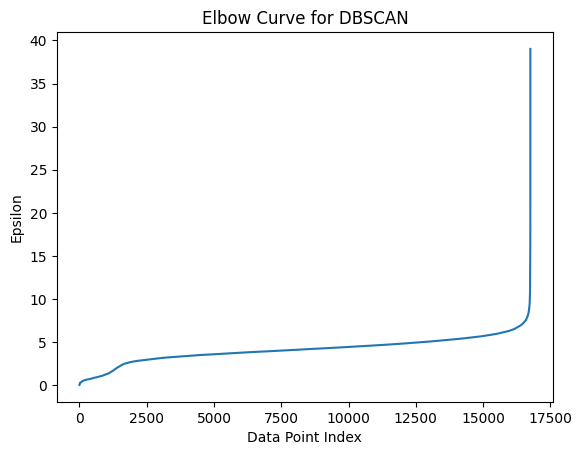

Optimal epsilon: 8.214042889074067
Number of outliers: 94
     Gender   Income  Customer Lifetime Value  EnrollmentType  \
430       1  10892.0                  5010.45               0   
450       0  65775.0                  5674.14               0   
546       0      0.0                  7200.66               0   
901       0  58414.0                  7840.17               0   
963       0  77330.0                  7988.26               0   

     rejoined_program  Days_in_prog  Cancelled_program  Enrollment_year  \
430                 0           3.0                  0             2021   
450                 0        2281.0                  0             2015   
546                 0          27.0                  0             2021   
901                 0           2.0                  0             2021   
963                 0           2.0                  0             2021   

     Enrollment_month  Location_cluster  TotalFlights  TotalDistance  \
430                12       

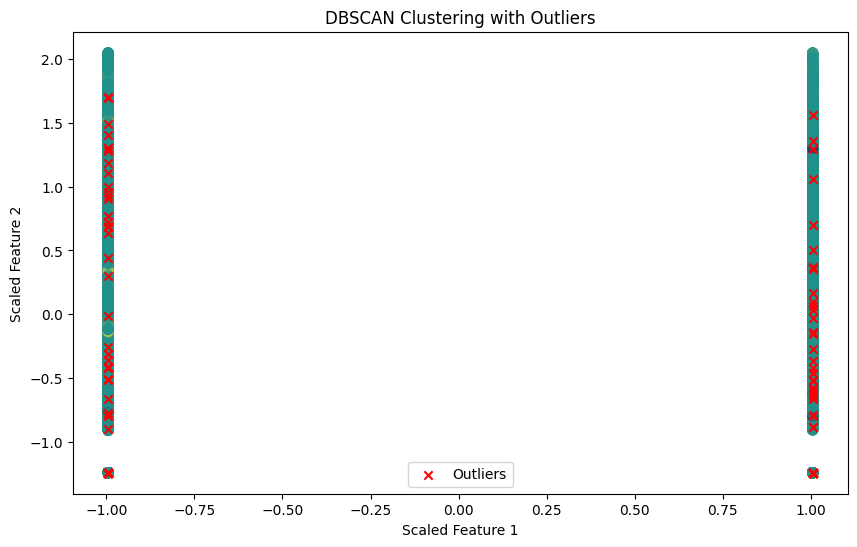

In [54]:
# Assuming you have a DataFrame named 'people' with purchase data

# Selecting relevant features for clustering
X = clustering_data.loc[:, ~clustering_data.columns.isin(['Loyalty#'])]

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculating the distance to the k-nearest neighbor
nearest_neighbors = NearestNeighbors(n_neighbors=5)
nearest_neighbors.fit(X_scaled)
distances, _ = nearest_neighbors.kneighbors(X_scaled)

# Sorting the distances and plotting the knee point
distances = np.sort(distances, axis=0)
distances = distances[:,1]  # consider the second nearest neighbor (the first one is itself)
plt.plot(distances)
plt.title("Elbow Curve for DBSCAN")
plt.xlabel("Data Point Index")
plt.ylabel("Epsilon")
plt.show()

# Finding the knee point to determine epsilon
kneedle = KneeLocator(range(len(distances)), distances, curve='convex', direction='increasing')
epsilon = distances[kneedle.knee]
print(f"Optimal epsilon: {epsilon}")

# Applying DBSCAN with the optimal epsilon
dbscan = DBSCAN(eps=epsilon, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Extracting outliers
outliers_mask = clusters == -1
outliers = X[outliers_mask]

print("Number of outliers:", len(outliers))

# You can further analyze the outliers as needed
print(outliers.head())

# Visualizing the clusters
plt.figure(figsize=(10, 6))

# Plotting points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.5)
plt.scatter(X_scaled[outliers_mask, 0], X_scaled[outliers_mask, 1], c='red', marker='x', label='Outliers')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('DBSCAN Clustering with Outliers')

plt.legend()
plt.show()

In [55]:
# 1. Create a boolean mask for the non-outliers (everything that is NOT -1)
mask_clean = clusters != -1

# 2. Filter your original DataFrame (assuming it is named 'clustering_data' or 'X')
# We use .copy() to ensure we have a standalone object, not a slice
df_clean = clustering_data[mask_clean].copy()

# 4. Verify the results
print(f"Original Dataset Size: {clustering_data.shape[0]}")
print(f"New Dataset Size: {df_clean.shape[0]}")
print(f"Successfully removed {clustering_data.shape[0] - df_clean.shape[0]} outliers.")

Original Dataset Size: 16757
New Dataset Size: 16663
Successfully removed 94 outliers.


In [56]:
#I decided to drop the 95 outliers identified by DBSCAN because they represent extreme 'edge cases' that were skewing the analysis. 
# These records included unusual data points—like customers with zero income but massive spending, or 'super travelers' with flight distances 100x the average. 
# By removing this small slice (<0.6% of the data), the remaining clusters will be much cleaner and more representative of the 
# typical customer base we are trying to model.

#texto rascunho de porque se deu drop

In [57]:
df_clean = df_clean.set_index('Loyalty#')
df_clean


,Gender,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,TotalDistance,TotalPointsAccumulated,TotalPointsRedeemed,RecencyInMonths,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12,Total_Spend_Month_1,Total_Spend_Month_2,Total_Spend_Month_3,Total_Spend_Month_4,Total_Spend_Month_5,Total_Spend_Month_6,Total_Spend_Month_7,Total_Spend_Month_8,Total_Spend_Month_9,Total_Spend_Month_10,Total_Spend_Month_11,Total_Spend_Month_12,TotalFlightsWithCompanions,TotalFlightSpend,PctFlightsWithCompanions,PctPointsSpent,Avg_Flights_per_day,Avg_spent_per_flight,Loyalty_Aurora,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100011,0,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,1,0,0,0,0,0,1,0
100012,1,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,1,0,0,0,0,0,0,1
100013,0,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,1,0,0,0,0,0,1,0
100014,1,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,1,0,0,0,0,0,1,0
100015,0,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,0,1,0,0,0,0,1,0
999996,0,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,1,0,0,0,0,0,0,1
999997,1,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,0.0,0.0,0.0,999.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,64.6,0.234242,0.215097,0.212291,59.007561,0,0,1,0,1,0,0,0,0,1,0


In [58]:
df_clean.to_csv("../data/cleaned_data/clustering_data_cleaned.csv")